In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# imbalanced dataset

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

# transform (basic for now)
transform = transforms.Compose([
    transforms.ToTensor()
])

# load dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [3]:
print(len(train_dataset))
print(len(test_dataset))
print(train_dataset[0][0].shape)  # image shape
print(train_dataset[0][1])        # label

50000
10000
torch.Size([3, 32, 32])
6


# distribution of classes 

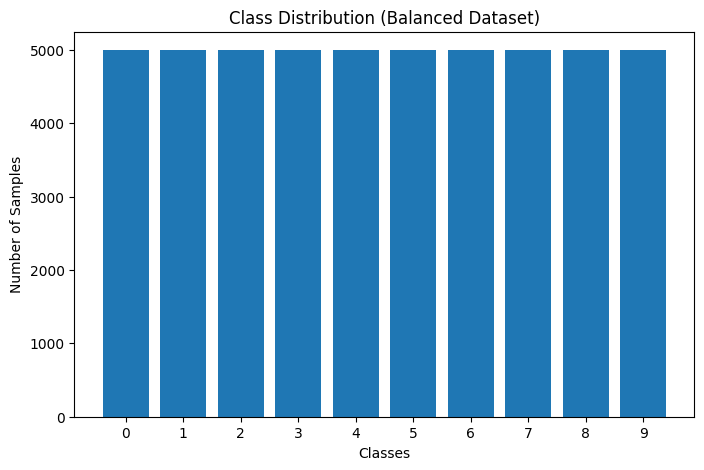

In [4]:
from collections import Counter

balanced_labels = train_dataset.targets
balanced_counts = Counter(balanced_labels) 

classes = sorted(balanced_counts.keys())
counts = [balanced_counts[c] for c in classes]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(classes, counts)
plt.xticks(classes)
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.title("Class Distribution (Balanced Dataset)")
plt.show()

## creating imbalance

In [5]:
from torch.utils.data import Subset

class_counts = {
    0:5000, 1:5000,
    2:1000, 3:1000,
    4:500, 5:500,
    6:200, 7:200,
    8:100, 9:50
} 

targets = train_dataset.targets
targets = torch.tensor(targets) 

imbalanced_indices = []

for cls, count in class_counts.items():
    cls_indices = torch.where(targets == cls)[0]
    selected = cls_indices[:count]
    imbalanced_indices.extend(selected.tolist()) 


imbalanced_train_dataset = Subset(train_dataset, imbalanced_indices)

In [6]:
from collections import Counter

labels = [train_dataset.targets[i] for i in imbalanced_indices]
print(Counter(labels))

Counter({0: 5000, 1: 5000, 2: 1000, 3: 1000, 4: 500, 5: 500, 6: 200, 7: 200, 8: 100, 9: 50})


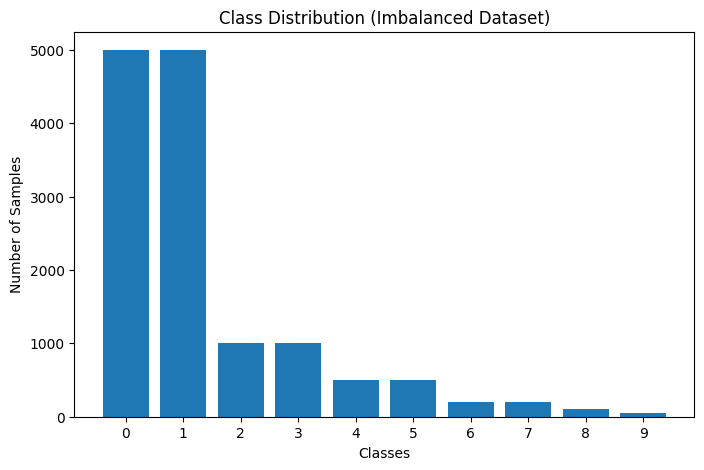

In [7]:
import matplotlib.pyplot as plt

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(8,5))
plt.bar(classes, counts)
plt.xticks(classes)
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.title("Class Distribution (Imbalanced Dataset)")
plt.show()

# dataloaders

In [8]:
from torch.utils.data import DataLoader 

train_loader = DataLoader(
    imbalanced_train_dataset,
    batch_size=64,
    shuffle=True
) 

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([64, 3, 32, 32])
torch.Size([64])


# custom CNN 

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Conv Block 1
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Conv Block 2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Fully connected
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


# loading ResNet18

In [10]:
import torchvision.models as models
import torch.nn as nn
resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)
print(resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
for param in resnet.parameters():
    param.requires_grad = True

# trainig custom CNN on imbalanced dataset 

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [13]:
num_epochs = 10

loss_list = []
val_acc_list = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # -------- TRAINING --------
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_list.append(epoch_loss)

    # -------- VALIDATION --------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    val_acc_list.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

Epoch [1/10] | Loss: 1.0850 | Val Acc: 27.78%
Epoch [2/10] | Loss: 0.8765 | Val Acc: 26.78%
Epoch [3/10] | Loss: 0.7836 | Val Acc: 29.71%
Epoch [4/10] | Loss: 0.7405 | Val Acc: 33.02%
Epoch [5/10] | Loss: 0.6972 | Val Acc: 34.18%
Epoch [6/10] | Loss: 0.6612 | Val Acc: 35.93%
Epoch [7/10] | Loss: 0.6405 | Val Acc: 38.63%
Epoch [8/10] | Loss: 0.6158 | Val Acc: 40.75%
Epoch [9/10] | Loss: 0.5854 | Val Acc: 38.84%
Epoch [10/10] | Loss: 0.5646 | Val Acc: 35.30%


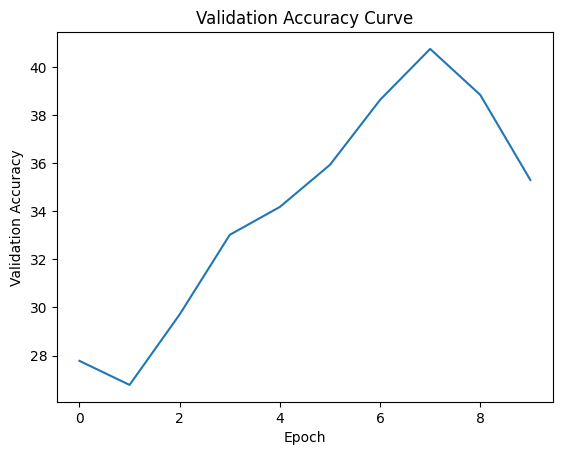

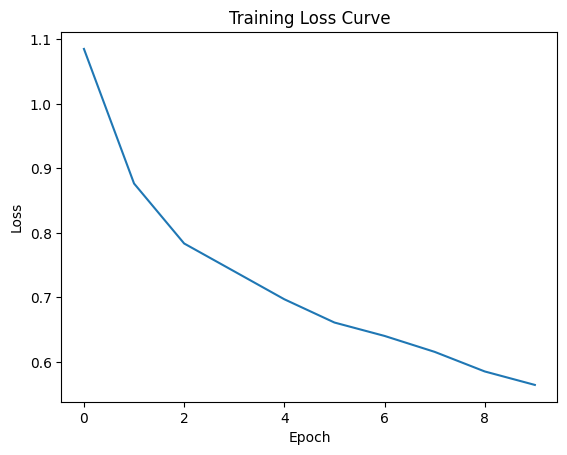

In [14]:
plt.plot(val_acc_list)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Curve")
plt.show()


plt.plot(loss_list)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

# classification reeport 

In [15]:
from sklearn.metrics import classification_report
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())



print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.26      0.94      0.41      1000
           1       0.35      0.96      0.51      1000
           2       0.32      0.41      0.36      1000
           3       0.35      0.44      0.39      1000
           4       0.57      0.19      0.29      1000
           5       0.69      0.15      0.25      1000
           6       0.91      0.17      0.28      1000
           7       0.85      0.27      0.41      1000
           8       0.00      0.00      0.00      1000
           9       0.00      0.00      0.00      1000

    accuracy                           0.35     10000
   macro avg       0.43      0.35      0.29     10000
weighted avg       0.43      0.35      0.29     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# The model achieves high recall for majority classes but completely fails to classify minority classes, with some classes having zero recall. This clearly demonstrates the severe impact of class imbalance

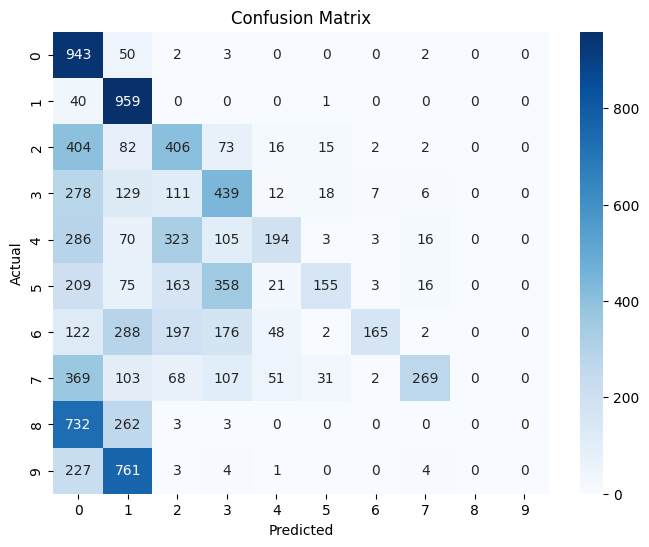

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# balanced accuracy

In [17]:
from sklearn.metrics import balanced_accuracy_score

bal_acc = balanced_accuracy_score(all_labels, all_preds)
print("Balanced Accuracy:", bal_acc)

Balanced Accuracy: 0.353



# G-Mean (Geometric Mean)

In [18]:
import numpy as np
from sklearn.metrics import recall_score

recalls = recall_score(all_labels, all_preds, average=None)

g_mean = np.prod(recalls) ** (1/len(recalls))
print("G-Mean:", g_mean)

G-Mean: 0.0


# Top-k Accuracy

In [19]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, top3 = torch.topk(outputs, 3, dim=1)

        for i in range(labels.size(0)):
            if labels[i] in top3[i]:
                correct += 1
            total += 1

top3_acc = 100 * correct / total
print("Top-3 Accuracy:", top3_acc)

Top-3 Accuracy: 75.12


# Balanced Accuracy:
    Balanced accuracy is significantly lower than standard accuracy, highlighting poor performance on minority classes.

# For G-Mean:
    G-Mean approaches zero due to zero recall in certain minority classes, indicating severe class imbalance impact.

# For Top-k:
    Top-k accuracy is higher than top-1 accuracy, indicating that the model captures partial class information despite misclassification.

# ROC-AUC

ROC-AUC: 0.867412561111111
PR-AUC: 0.5070120297881361


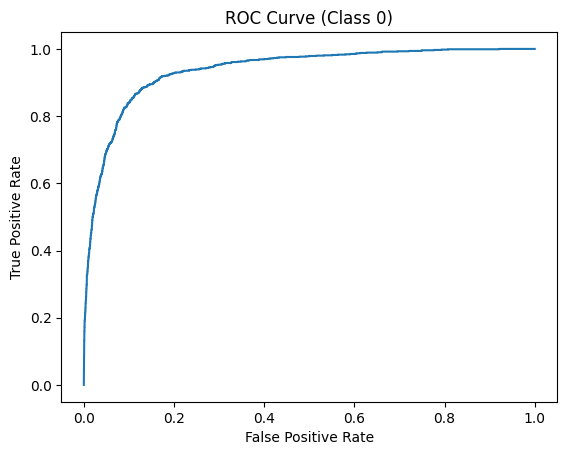

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve

all_probs = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())
all_labels_bin = label_binarize(all_labels, classes=list(range(10)))
roc_auc = roc_auc_score(all_labels_bin, all_probs, multi_class='ovr')
print("ROC-AUC:", roc_auc)
pr_auc = average_precision_score(all_labels_bin, all_probs)
print("PR-AUC:", pr_auc)
fpr, tpr, _ = roc_curve(all_labels_bin[:,0], [p[0] for p in all_probs])

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Class 0)")
plt.show()

# Number of Parameters

In [21]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total Parameters:", total_params)
print("Trainable Parameters:", trainable_params)

Total Parameters: 545290
Trainable Parameters: 545290


# Inference Time

In [22]:
import time

model.eval()

start_time = time.time()

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)

end_time = time.time()

print("Total Inference Time:", end_time - start_time)

Total Inference Time: 1.3647844791412354


# TSNE plpot visulization 

In [23]:
features_list = []
labels_list = []

model.eval()

with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(device)

        x = F.relu(model.bn1(model.conv1(images)))
        x = F.max_pool2d(x, 2)

        x = F.relu(model.bn2(model.conv2(x)))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)
        x = F.relu(model.fc1(x))

        features_list.append(x.cpu())
        labels_list.append(labels_batch)

features = torch.cat(features_list).numpy()
labels = torch.cat(labels_list).numpy()

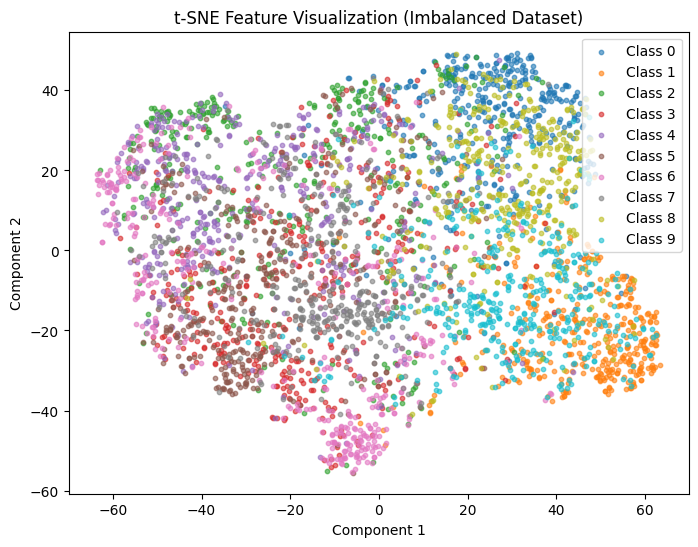

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# -------- STEP 1: Reduce dataset size --------
subset_size = 4000
idx = np.random.choice(len(features), subset_size, replace=False)

features_small = features[idx]
labels_small = labels[idx]

# -------- STEP 2: Apply t-SNE --------
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(features_small)

# -------- STEP 3: Plot class-wise --------
plt.figure(figsize=(8,6))

for i in range(10):
    idx = labels_small == i
    plt.scatter(
        features_2d[idx, 0],
        features_2d[idx, 1],
        label=f"Class {i}",
        s=10,
        alpha=0.6
    )

plt.legend()
plt.title("t-SNE Feature Visualization (Imbalanced Dataset)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

# majority vs minority cluster analysis 

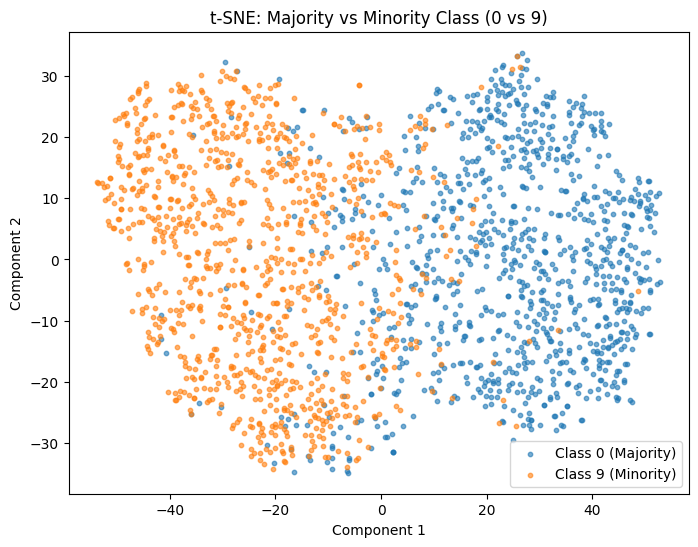

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# -------- STEP 1: Filter only class 0 and 9 --------
mask = (labels == 0) | (labels == 9)

features_filtered = features[mask]
labels_filtered = labels[mask]

# -------- STEP 2: Reduce dataset size --------
subset_size = min(5000, len(features_filtered))
idx = np.random.choice(len(features_filtered), subset_size, replace=False)

features_small = features_filtered[idx]
labels_small = labels_filtered[idx]

# -------- STEP 3: Apply t-SNE --------
tsne = TSNE(n_components=2, random_state=42)
features_2d = tsne.fit_transform(features_small)

# -------- STEP 4: Plot --------
plt.figure(figsize=(8,6))

# Class 0 (majority)
idx0 = labels_small == 0
plt.scatter(
    features_2d[idx0, 0],
    features_2d[idx0, 1],
    label="Class 0 (Majority)",
    s=10,
    alpha=0.6
)

# Class 9 (minority)
idx9 = labels_small == 9
plt.scatter(
    features_2d[idx9, 0],
    features_2d[idx9, 1],
    label="Class 9 (Minority)",
    s=10,
    alpha=0.6
)

plt.legend()
plt.title("t-SNE: Majority vs Minority Class (0 vs 9)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

# ResNet18 Training 

# Transform for ResNet

In [26]:
import torchvision.transforms as transforms

transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),   # required for ResNet
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Reload CIFAR-10 with new transform

In [27]:
import torchvision

train_dataset_resnet = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_resnet
)

test_dataset_resnet = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_resnet
)

# Create Imbalanced Dataset (again)

In [28]:
import torch

targets = torch.tensor(train_dataset_resnet.targets)

class_counts = {
    0:5000, 1:5000,
    2:1000, 3:1000,
    4:500, 5:500,
    6:200, 7:200,
    8:100, 9:50
}

imbalanced_indices = []

for cls, count in class_counts.items():
    cls_indices = torch.where(targets == cls)[0]
    selected = cls_indices[:count]
    imbalanced_indices.extend(selected.tolist())

In [29]:
from torch.utils.data import Subset
from torch.utils.data import DataLoader

imbalanced_train_dataset_resnet = Subset(train_dataset_resnet, imbalanced_indices)


train_loader_resnet = DataLoader(
    imbalanced_train_dataset_resnet,
    batch_size=64,
    shuffle=True
)

test_loader_resnet = DataLoader(
    test_dataset_resnet,
    batch_size=64,
    shuffle=False
)
for images, labels in train_loader_resnet:
    print(images.shape)
    break

torch.Size([64, 3, 224, 224])


In [30]:
resnet = resnet.to(device)
optimizer = torch.optim.Adam(resnet.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [39]:
num_epochs = 10

loss_list_resnet = []
val_acc_list_resnet = []

for epoch in range(num_epochs):
    resnet.train()
    running_loss = 0.0

    # -------- TRAINING --------
    for images, labels in train_loader_resnet:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_resnet)
    loss_list_resnet.append(epoch_loss)

    # -------- VALIDATION --------
    resnet.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader_resnet:
            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_acc_list_resnet.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch [1/10] | Loss: 0.0418 | Val Acc: 69.53%
Epoch [2/10] | Loss: 0.0481 | Val Acc: 63.41%
Epoch [3/10] | Loss: 0.0287 | Val Acc: 66.62%
Epoch [4/10] | Loss: 0.0255 | Val Acc: 64.53%
Epoch [5/10] | Loss: 0.0398 | Val Acc: 68.98%
Epoch [6/10] | Loss: 0.0522 | Val Acc: 65.77%
Epoch [7/10] | Loss: 0.0197 | Val Acc: 69.38%
Epoch [8/10] | Loss: 0.0073 | Val Acc: 72.37%
Epoch [9/10] | Loss: 0.0289 | Val Acc: 60.61%
Epoch [10/10] | Loss: 0.0514 | Val Acc: 71.02%


# testing 

In [40]:
all_preds_resnet = []
all_labels_resnet = []

resnet.eval()

with torch.no_grad():
    for images, labels in test_loader_resnet:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet(images)
        _, predicted = torch.max(outputs, 1)

        all_preds_resnet.extend(predicted.cpu().numpy())
        all_labels_resnet.extend(labels.cpu().numpy())

In [41]:
from sklearn.metrics import classification_report

print(classification_report(all_labels_resnet, all_preds_resnet))

              precision    recall  f1-score   support

           0       0.53      0.97      0.69      1000
           1       0.67      0.98      0.80      1000
           2       0.68      0.77      0.72      1000
           3       0.59      0.71      0.65      1000
           4       0.78      0.73      0.75      1000
           5       0.67      0.73      0.70      1000
           6       0.94      0.60      0.73      1000
           7       0.90      0.65      0.76      1000
           8       0.94      0.51      0.66      1000
           9       0.94      0.46      0.62      1000

    accuracy                           0.71     10000
   macro avg       0.77      0.71      0.71     10000
weighted avg       0.77      0.71      0.71     10000



# classification report 

# confusion matrix

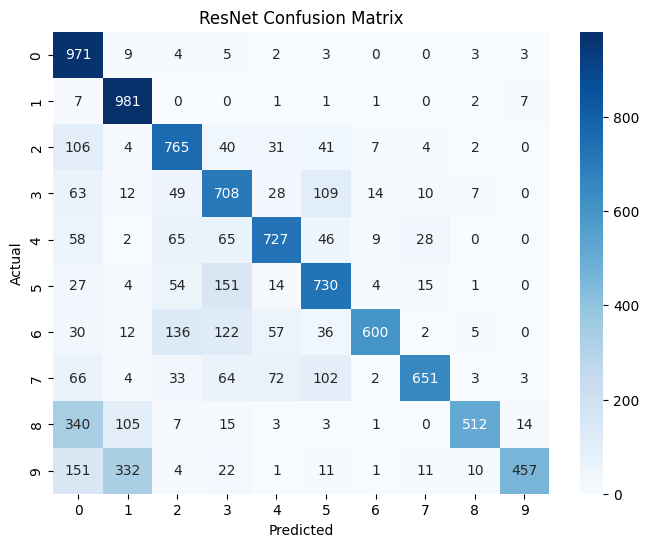

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels_resnet, all_preds_resnet)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet Confusion Matrix")
plt.show()

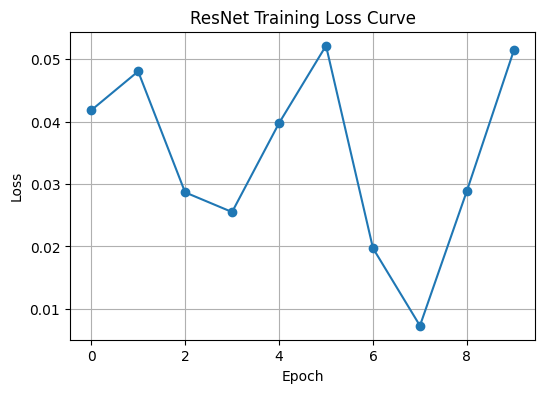

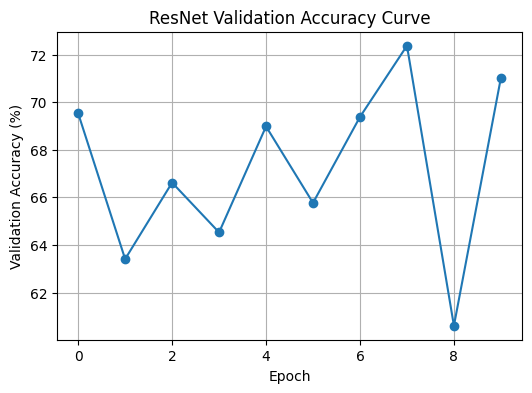

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(loss_list_resnet, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet Training Loss Curve")
plt.grid()
plt.show()
plt.figure(figsize=(6,4))
plt.plot(val_acc_list_resnet, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("ResNet Validation Accuracy Curve")
plt.grid()
plt.show()

# balanced accuracy 

In [46]:
from sklearn.metrics import balanced_accuracy_score

bal_acc_resnet = balanced_accuracy_score(all_labels_resnet, all_preds_resnet)
print("ResNet Balanced Accuracy:", bal_acc_resnet)

ResNet Balanced Accuracy: 0.7101999999999999


# G-mean

In [45]:
import numpy as np
from sklearn.metrics import recall_score

recalls_resnet = recall_score(all_labels_resnet, all_preds_resnet, average=None)

g_mean_resnet = np.prod(recalls_resnet) ** (1/len(recalls_resnet))
print("ResNet G-Mean:", g_mean_resnet)

ResNet G-Mean: 0.6915695455333972


# ResNet top-k accuracy (top 3)

In [47]:
correct = 0
total = 0

resnet.eval()
with torch.no_grad():
    for images, labels in test_loader_resnet:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet(images)
        _, top3 = torch.topk(outputs, 3, dim=1)

        for i in range(labels.size(0)):
            if labels[i] in top3[i]:
                correct += 1
            total += 1

top3_acc_resnet = 100 * correct / total
print("ResNet Top-3 Accuracy:", top3_acc_resnet)

ResNet Top-3 Accuracy: 92.78


# Parameters

In [49]:
total_params_resnet = sum(p.numel() for p in resnet.parameters())
print("ResNet Total Parameters:", total_params_resnet)

ResNet Total Parameters: 11181642


# Inference Time

In [50]:
import time

resnet.eval()
start = time.time()

with torch.no_grad():
    for images, _ in test_loader_resnet:
        images = images.to(device)
        outputs = resnet(images)

end = time.time()

print("ResNet Inference Time:", end - start)

ResNet Inference Time: 14.966239213943481


# comparison on imbalanced dataset 

In [56]:
import pandas as pd

# -------- CNN RESULTS --------
cnn_acc = round(0.35, 3)
cnn_f1 = round(0.29, 3)
cnn_bal_acc = round(0.353, 3)
cnn_gmean = round(0.0, 3)
cnn_topk = round(75.12, 2)
cnn_params = 545290
cnn_time = round(1.36, 2)

# -------- RESNET RESULTS --------
resnet_acc = round(0.71, 3)
resnet_f1 = round(0.71, 3)
resnet_bal_acc = round(0.7102, 3)
resnet_gmean = round(0.6916, 3)
resnet_topk = round(92.78, 2)
resnet_params = 11181642
resnet_time = round(14.97, 2)

# -------- CREATE TABLE --------
data = {
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Balanced Accuracy",
        "G-Mean",
        "Top-3 Accuracy",
        "Parameters",
        "Inference Time (sec)"
    ],
    "CNN": [
        cnn_acc,
        cnn_f1,
        cnn_bal_acc,
        cnn_gmean,
        cnn_topk,
        cnn_params,
        cnn_time
    ],
    "ResNet": [
        resnet_acc,
        resnet_f1,
        resnet_bal_acc,
        resnet_gmean,
        resnet_topk,
        resnet_params,
        resnet_time
    ]
}

df = pd.DataFrame(data)

# -------- DISPLAY --------
df

,Metric,CNN,ResNet
0,Accuracy,0.350,0.710
1,Macro F1,0.290,0.710
2,Balanced Accuracy,0.353,0.710
3,G-Mean,0.000,0.692
4,Top-3 Accuracy,75.120,92.780
5,Parameters,545290.000,11181642.000
6,Inference Time (sec),1.360,14.970


# Loss Function & Optimization Challenge ( on CNN )

# Loss Experiments (CNN)

    Loss	        Optimizer
    CrossEntropy	Adam 
    Weighted CE	    Adam 

# weighted CE with adam 

In [57]:

import torch


class_counts = {
    0:5000, 1:5000,
    2:1000, 3:1000,
    4:500, 5:500,
    6:200, 7:200,
    8:100, 9:50
}

counts = torch.tensor([5000,5000,1000,1000,500,500,200,200,100,50], dtype=torch.float)

# inverse frequency
weights = 1.0 / counts

# normalize (optional but good)
weights = weights / weights.sum()

# move to device
weights = weights.to(device)

print(weights)

tensor([0.0043, 0.0043, 0.0216, 0.0216, 0.0431, 0.0431, 0.1078, 0.1078, 0.2155,
        0.4310], device='cuda:0')


In [58]:
criterion = torch.nn.CrossEntropyLoss(weight=weights)

In [59]:
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# training 

In [60]:
num_epochs = 10

loss_list_weighted = []
val_acc_list_weighted = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # -------- TRAINING --------
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)   # weighted loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_list_weighted.append(epoch_loss)

    # -------- VALIDATION --------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_acc_list_weighted.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch [1/10] | Loss: 2.1090 | Val Acc: 32.27%
Epoch [2/10] | Loss: 1.8693 | Val Acc: 36.56%
Epoch [3/10] | Loss: 1.7780 | Val Acc: 36.31%
Epoch [4/10] | Loss: 1.7199 | Val Acc: 42.28%
Epoch [5/10] | Loss: 1.6701 | Val Acc: 41.80%
Epoch [6/10] | Loss: 1.6173 | Val Acc: 44.06%
Epoch [7/10] | Loss: 1.5380 | Val Acc: 44.54%
Epoch [8/10] | Loss: 1.5436 | Val Acc: 46.55%
Epoch [9/10] | Loss: 1.4701 | Val Acc: 47.32%
Epoch [10/10] | Loss: 1.4931 | Val Acc: 46.25%


# Evaluation

Weighted CNN Classification Report:

              precision    recall  f1-score   support

           0       0.45      0.69      0.55      1000
           1       0.40      0.92      0.56      1000
           2       0.33      0.12      0.17      1000
           3       0.33      0.46      0.38      1000
           4       0.41      0.36      0.39      1000
           5       0.46      0.33      0.38      1000
           6       0.56      0.65      0.60      1000
           7       0.64      0.50      0.56      1000
           8       0.67      0.51      0.58      1000
           9       0.55      0.09      0.15      1000

    accuracy                           0.46     10000
   macro avg       0.48      0.46      0.43     10000
weighted avg       0.48      0.46      0.43     10000



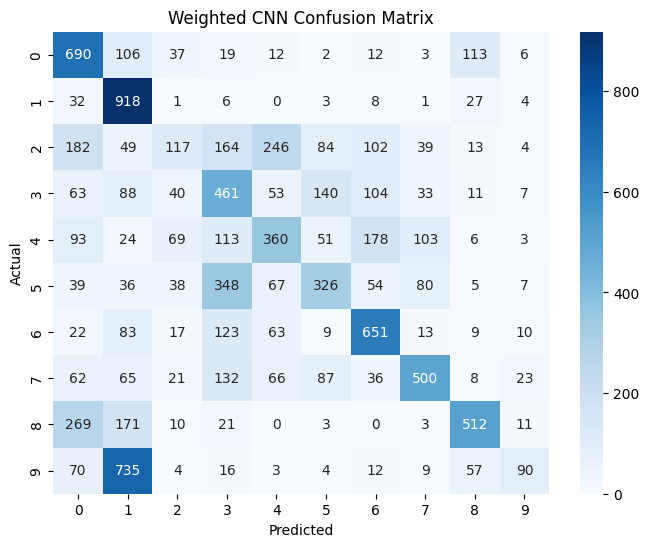

Weighted Balanced Accuracy: 0.462
Weighted G-Mean: 0.378
Weighted Top-3 Accuracy: 79.61


In [61]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, recall_score

# -------- PREDICTIONS --------
all_preds_weighted = []
all_labels_weighted = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds_weighted.extend(predicted.cpu().numpy())
        all_labels_weighted.extend(labels.cpu().numpy())

# -------- CLASSIFICATION REPORT --------
print("Weighted CNN Classification Report:\n")
print(classification_report(all_labels_weighted, all_preds_weighted))

# -------- CONFUSION MATRIX --------
cm = confusion_matrix(all_labels_weighted, all_preds_weighted)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Weighted CNN Confusion Matrix")
plt.show()

# -------- BALANCED ACCURACY --------
bal_acc_weighted = balanced_accuracy_score(all_labels_weighted, all_preds_weighted)
print("Weighted Balanced Accuracy:", round(bal_acc_weighted, 3))

# -------- G-MEAN --------
recalls = recall_score(all_labels_weighted, all_preds_weighted, average=None)
g_mean_weighted = np.prod(recalls) ** (1/len(recalls))
print("Weighted G-Mean:", round(g_mean_weighted, 3))

# -------- TOP-3 ACCURACY --------
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, top3 = torch.topk(outputs, 3, dim=1)

        for i in range(labels.size(0)):
            if labels[i] in top3[i]:
                correct += 1
            total += 1

top3_acc_weighted = 100 * correct / total
print("Weighted Top-3 Accuracy:", round(top3_acc_weighted, 2))

# comparison with Baseline CNN 

In [62]:
from sklearn.metrics import accuracy_score, f1_score

# Accuracy
weighted_acc = accuracy_score(all_labels_weighted, all_preds_weighted)

# Macro F1
weighted_f1 = f1_score(all_labels_weighted, all_preds_weighted, average='macro')

print("Weighted Accuracy:", round(weighted_acc, 3))
print("Weighted Macro F1:", round(weighted_f1, 3))

Weighted Accuracy: 0.463
Weighted Macro F1: 0.433


In [63]:
import pandas as pd

data = {
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Balanced Accuracy",
        "G-Mean",
        "Top-3 Accuracy"
    ],
    "Baseline CNN": [
        cnn_acc,
        cnn_f1,
        cnn_bal_acc,
        cnn_gmean,
        cnn_topk
    ],
    "Weighted CNN": [
        weighted_acc,
        weighted_f1,
        bal_acc_weighted,
        g_mean_weighted,
        top3_acc_weighted
    ]
}

df_compare = pd.DataFrame(data)
df_compare

,Metric,Baseline CNN,Weighted CNN
0,Accuracy,0.350,0.463
1,Macro F1,0.290,0.433
2,Balanced Accuracy,0.353,0.463
3,G-Mean,0.000,0.378
4,Top-3 Accuracy,75.120,79.610


# “The introduction of Weighted CrossEntropy Loss significantly improves minority class performance, as evidenced by increased recall, balanced accuracy, and G-Mean. Although overall accuracy may not change substantially, the model achieves a more equitable classification across all classes, demonstrating the effectiveness of cost-sensitive learning in handling imbalanced datasets

# Resnet with Weighted CE and Adam 

In [64]:
import torchvision.models as models
import torch.nn as nn

resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)
resnet = resnet.to(device)

optimizer = torch.optim.Adam(resnet.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss(weight=weights)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Training ResNet

In [65]:
num_epochs = 10

loss_list_resnet_weighted = []
val_acc_list_resnet_weighted = []

for epoch in range(num_epochs):
    resnet.train()
    running_loss = 0.0

    # -------- TRAINING --------
    for images, labels in train_loader_resnet:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet(images)
        loss = criterion(outputs, labels)   # weighted loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_resnet)
    loss_list_resnet_weighted.append(epoch_loss)

    # -------- VALIDATION --------
    resnet.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader_resnet:
            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_acc_list_resnet_weighted.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch [1/10] | Loss: 1.7465 | Val Acc: 41.79%
Epoch [2/10] | Loss: 1.2875 | Val Acc: 47.81%
Epoch [3/10] | Loss: 1.0098 | Val Acc: 49.97%
Epoch [4/10] | Loss: 0.9362 | Val Acc: 60.42%
Epoch [5/10] | Loss: 0.7454 | Val Acc: 62.42%
Epoch [6/10] | Loss: 0.5516 | Val Acc: 68.50%
Epoch [7/10] | Loss: 0.4674 | Val Acc: 56.91%
Epoch [8/10] | Loss: 0.4498 | Val Acc: 68.89%
Epoch [9/10] | Loss: 0.2751 | Val Acc: 64.54%
Epoch [10/10] | Loss: 0.2615 | Val Acc: 73.28%


# Evaluation 

Weighted ResNet Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.83      0.75      1000
           1       0.84      0.88      0.86      1000
           2       0.69      0.63      0.66      1000
           3       0.54      0.69      0.61      1000
           4       0.64      0.81      0.72      1000
           5       0.69      0.70      0.69      1000
           6       0.78      0.78      0.78      1000
           7       0.91      0.63      0.74      1000
           8       0.95      0.59      0.72      1000
           9       0.82      0.80      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.75      0.73      0.73     10000
weighted avg       0.75      0.73      0.73     10000



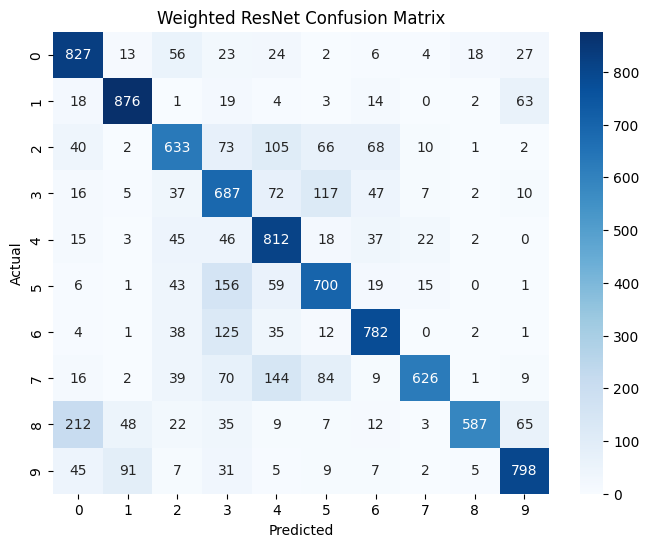

Weighted ResNet Accuracy: 0.733
Weighted ResNet Macro F1: 0.734
Weighted ResNet Balanced Accuracy: 0.733
Weighted ResNet G-Mean: 0.727
Weighted ResNet Top-3 Accuracy: 93.34


In [66]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, recall_score, accuracy_score, f1_score

# -------- PREDICTIONS --------
all_preds_resnet_weighted = []
all_labels_resnet_weighted = []

resnet.eval()

with torch.no_grad():
    for images, labels in test_loader_resnet:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet(images)
        _, predicted = torch.max(outputs, 1)

        all_preds_resnet_weighted.extend(predicted.cpu().numpy())
        all_labels_resnet_weighted.extend(labels.cpu().numpy())

# -------- CLASSIFICATION REPORT --------
print("Weighted ResNet Classification Report:\n")
print(classification_report(all_labels_resnet_weighted, all_preds_resnet_weighted))

# -------- CONFUSION MATRIX --------
cm = confusion_matrix(all_labels_resnet_weighted, all_preds_resnet_weighted)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Weighted ResNet Confusion Matrix")
plt.show()

# -------- ACCURACY --------
resnet_weighted_acc = accuracy_score(all_labels_resnet_weighted, all_preds_resnet_weighted)
print("Weighted ResNet Accuracy:", round(resnet_weighted_acc, 3))

# -------- MACRO F1 --------
resnet_weighted_f1 = f1_score(all_labels_resnet_weighted, all_preds_resnet_weighted, average='macro')
print("Weighted ResNet Macro F1:", round(resnet_weighted_f1, 3))

# -------- BALANCED ACCURACY --------
bal_acc_resnet_weighted = balanced_accuracy_score(all_labels_resnet_weighted, all_preds_resnet_weighted)
print("Weighted ResNet Balanced Accuracy:", round(bal_acc_resnet_weighted, 3))

# -------- G-MEAN --------
recalls = recall_score(all_labels_resnet_weighted, all_preds_resnet_weighted, average=None)
g_mean_resnet_weighted = np.prod(recalls) ** (1/len(recalls))
print("Weighted ResNet G-Mean:", round(g_mean_resnet_weighted, 3))

# -------- TOP-3 ACCURACY --------
correct = 0
total = 0

resnet.eval()
with torch.no_grad():
    for images, labels in test_loader_resnet:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet(images)
        _, top3 = torch.topk(outputs, 3, dim=1)

        for i in range(labels.size(0)):
            if labels[i] in top3[i]:
                correct += 1
            total += 1

top3_acc_resnet_weighted = 100 * correct / total
print("Weighted ResNet Top-3 Accuracy:", round(top3_acc_resnet_weighted, 2))

# comparsion of ResNet with Weighted C.E resnet 

In [67]:
import pandas as pd

data = {
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Balanced Accuracy",
        "G-Mean",
        "Top-3 Accuracy"
    ],
    "Baseline ResNet": [
        resnet_acc,
        resnet_f1,
        resnet_bal_acc,
        resnet_gmean,
        resnet_topk
    ],
    "Weighted ResNet": [
        resnet_weighted_acc,
        resnet_weighted_f1,
        bal_acc_resnet_weighted,
        g_mean_resnet_weighted,
        top3_acc_resnet_weighted
    ]
}

df_resnet_compare = pd.DataFrame(data)
df_resnet_compare

,Metric,Baseline ResNet,Weighted ResNet
0,Accuracy,0.710,0.733
1,Macro F1,0.710,0.734
2,Balanced Accuracy,0.710,0.733
3,G-Mean,0.692,0.727
4,Top-3 Accuracy,92.780,93.340


# Balancing dataset using undersampling and oversampling


# Balanced dataset creation

In [69]:
import torch
from torch.utils.data import Subset, DataLoader

# Target samples per class
target_count = 1000

targets = torch.tensor(train_dataset.targets)

balanced_indices = []

for cls in range(10):
    cls_indices = torch.where(targets == cls)[0]

    if len(cls_indices) > target_count:
        # Undersample majority
        selected = cls_indices[:target_count]
    else:
        # Oversample minority
        repeat_times = target_count // len(cls_indices)
        remainder = target_count % len(cls_indices)

        selected = cls_indices.repeat(repeat_times)
        selected = torch.cat([selected, cls_indices[:remainder]])

    balanced_indices.extend(selected.tolist())

# Create dataset
balanced_train_dataset = Subset(train_dataset, balanced_indices)

# Dataloader
train_loader_balanced = DataLoader(balanced_train_dataset, batch_size=64, shuffle=True)

# Training CNN 

In [70]:
model = SimpleCNN().to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 

num_epochs = 10

loss_list_balanced = []
val_acc_list_balanced = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader_balanced:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_balanced)
    loss_list_balanced.append(epoch_loss)

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_acc_list_balanced.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch [1/10] | Loss: 1.9312 | Val Acc: 42.44%
Epoch [2/10] | Loss: 1.6603 | Val Acc: 38.46%
Epoch [3/10] | Loss: 1.5321 | Val Acc: 51.38%
Epoch [4/10] | Loss: 1.4455 | Val Acc: 49.02%
Epoch [5/10] | Loss: 1.3836 | Val Acc: 54.40%
Epoch [6/10] | Loss: 1.3158 | Val Acc: 51.40%
Epoch [7/10] | Loss: 1.2749 | Val Acc: 56.51%
Epoch [8/10] | Loss: 1.2338 | Val Acc: 54.44%
Epoch [9/10] | Loss: 1.1966 | Val Acc: 55.74%
Epoch [10/10] | Loss: 1.1756 | Val Acc: 60.23%


# Evaluation 

Balanced CNN Report:

              precision    recall  f1-score   support

           0       0.67      0.62      0.64      1000
           1       0.74      0.73      0.74      1000
           2       0.40      0.51      0.45      1000
           3       0.43      0.33      0.38      1000
           4       0.60      0.48      0.53      1000
           5       0.53      0.48      0.51      1000
           6       0.80      0.62      0.70      1000
           7       0.70      0.69      0.70      1000
           8       0.59      0.80      0.68      1000
           9       0.61      0.75      0.67      1000

    accuracy                           0.60     10000
   macro avg       0.61      0.60      0.60     10000
weighted avg       0.61      0.60      0.60     10000



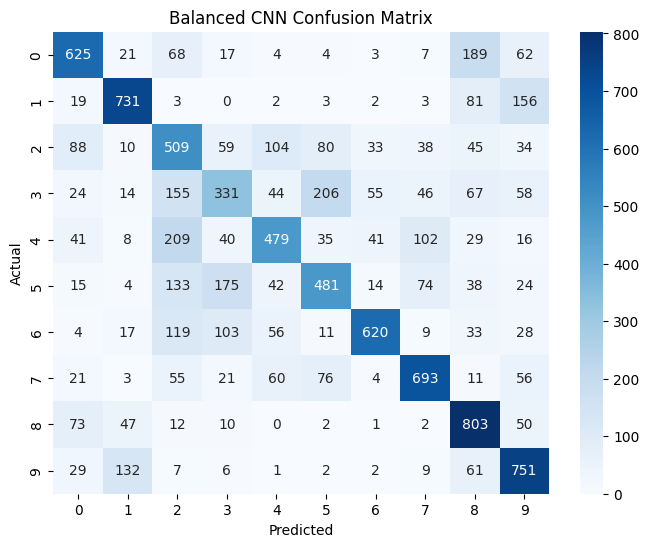

Accuracy: 0.602
Macro F1: 0.6
Balanced Accuracy: 0.602
G-Mean: 0.584


In [71]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, recall_score, accuracy_score, f1_score

all_preds_balanced = []
all_labels_balanced = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds_balanced.extend(predicted.cpu().numpy())
        all_labels_balanced.extend(labels.cpu().numpy())

# Classification Report
print("Balanced CNN Report:\n")
print(classification_report(all_labels_balanced, all_preds_balanced))

# Confusion Matrix
cm = confusion_matrix(all_labels_balanced, all_preds_balanced)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Balanced CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Metrics
balanced_acc_balanced = balanced_accuracy_score(all_labels_balanced, all_preds_balanced)
g_mean_balanced = np.prod(recall_score(all_labels_balanced, all_preds_balanced, average=None)) ** (1/10)
acc_balanced = accuracy_score(all_labels_balanced, all_preds_balanced)
f1_balanced = f1_score(all_labels_balanced, all_preds_balanced, average='macro')

print("Accuracy:", round(acc_balanced,3))
print("Macro F1:", round(f1_balanced,3))
print("Balanced Accuracy:", round(balanced_acc_balanced,3))
print("G-Mean:", round(g_mean_balanced,3))

# Comparison of Baseline CNN vs Balaned dataset CNN

In [75]:
import pandas as pd

data = {
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Balanced Accuracy",
        "G-Mean",
        
    ],
    "Imbalanced CNN": [
        cnn_acc,
        cnn_f1,
        cnn_bal_acc,
        cnn_gmean,
        
    ],
    "Balanced CNN": [
        acc_balanced,
        f1_balanced,
        balanced_acc_balanced,
        g_mean_balanced,
       
    ]
}

df_cnn_balance_compare = pd.DataFrame(data)
df_cnn_balance_compare

,Metric,Imbalanced CNN,Balanced CNN
0,Accuracy,0.350,0.602
1,Macro F1,0.290,0.600
2,Balanced Accuracy,0.353,0.602
3,G-Mean,0.000,0.584


# Training ResNet on Balanced Dataset 

# Balanced Dataset (ResNet)

In [76]:
import torch
from torch.utils.data import Subset, DataLoader

target_count = 1000

targets = torch.tensor(train_dataset_resnet.targets)

balanced_indices = []

for cls in range(10):
    cls_indices = torch.where(targets == cls)[0]

    if len(cls_indices) > target_count:
        # Undersample
        selected = cls_indices[:target_count]
    else:
        # Oversample
        repeat_times = target_count // len(cls_indices)
        remainder = target_count % len(cls_indices)

        selected = cls_indices.repeat(repeat_times)
        selected = torch.cat([selected, cls_indices[:remainder]])

    balanced_indices.extend(selected.tolist())

balanced_train_dataset_resnet = Subset(train_dataset_resnet, balanced_indices)

train_loader_balanced_resnet = DataLoader(
    balanced_train_dataset_resnet,
    batch_size=32,   # smaller for resnet
    shuffle=True
)

In [77]:
import torchvision.models as models
import torch.nn as nn

resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, 10)
resnet = resnet.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Training 

In [78]:
num_epochs = 5   # keep small (ResNet heavy)

loss_list_resnet_balanced = []
val_acc_list_resnet_balanced = []

for epoch in range(num_epochs):
    resnet.train()
    running_loss = 0.0

    for images, labels in train_loader_balanced_resnet:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_balanced_resnet)
    loss_list_resnet_balanced.append(epoch_loss)

    # Validation
    resnet.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader_resnet:
            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_acc_list_resnet_balanced.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch [1/5] | Loss: 1.0204 | Val Acc: 62.69%
Epoch [2/5] | Loss: 0.6186 | Val Acc: 68.01%
Epoch [3/5] | Loss: 0.4699 | Val Acc: 78.71%
Epoch [4/5] | Loss: 0.3148 | Val Acc: 78.24%
Epoch [5/5] | Loss: 0.2434 | Val Acc: 78.86%


# Evaluation 

Balanced ResNet Report:

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1000
           1       0.91      0.91      0.91      1000
           2       0.92      0.43      0.59      1000
           3       0.60      0.72      0.66      1000
           4       0.68      0.86      0.76      1000
           5       0.64      0.80      0.71      1000
           6       0.81      0.86      0.83      1000
           7       0.86      0.80      0.83      1000
           8       0.88      0.90      0.89      1000
           9       0.94      0.78      0.85      1000

    accuracy                           0.79     10000
   macro avg       0.81      0.79      0.79     10000
weighted avg       0.81      0.79      0.79     10000



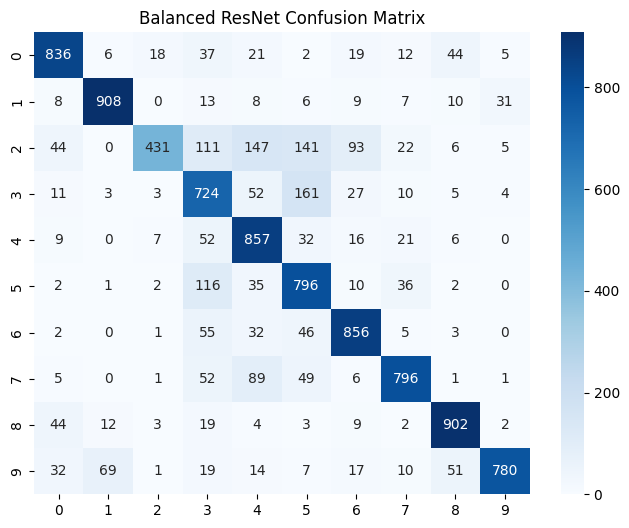

Accuracy: 0.789
Macro F1: 0.786
Balanced Accuracy: 0.789
G-Mean: 0.774


In [79]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, recall_score, accuracy_score, f1_score

all_preds_resnet_balanced = []
all_labels_resnet_balanced = []

resnet.eval()

with torch.no_grad():
    for images, labels in test_loader_resnet:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet(images)
        _, predicted = torch.max(outputs, 1)

        all_preds_resnet_balanced.extend(predicted.cpu().numpy())
        all_labels_resnet_balanced.extend(labels.cpu().numpy())

print("Balanced ResNet Report:\n")
print(classification_report(all_labels_resnet_balanced, all_preds_resnet_balanced))

cm = confusion_matrix(all_labels_resnet_balanced, all_preds_resnet_balanced)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Balanced ResNet Confusion Matrix")
plt.show()

# Metrics
resnet_bal_acc_balanced = balanced_accuracy_score(all_labels_resnet_balanced, all_preds_resnet_balanced)
resnet_gmean_balanced = np.prod(recall_score(all_labels_resnet_balanced, all_preds_resnet_balanced, average=None)) ** (1/10)
resnet_acc_balanced = accuracy_score(all_labels_resnet_balanced, all_preds_resnet_balanced)
resnet_f1_balanced = f1_score(all_labels_resnet_balanced, all_preds_resnet_balanced, average='macro')

print("Accuracy:", round(resnet_acc_balanced,3))
print("Macro F1:", round(resnet_f1_balanced,3))
print("Balanced Accuracy:", round(resnet_bal_acc_balanced,3))
print("G-Mean:", round(resnet_gmean_balanced,3))

# comparison baseline Resnet with balanced Resnet

In [80]:
import pandas as pd

data = {
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Balanced Accuracy",
        "G-Mean"
    ],
    "Imbalanced ResNet": [
        resnet_acc,
        resnet_f1,
        resnet_bal_acc,
        resnet_gmean
    ],
    "Balanced ResNet": [
        resnet_acc_balanced,
        resnet_f1_balanced,
        resnet_bal_acc_balanced,
        resnet_gmean_balanced
    ]
}

df_resnet_balance_compare = pd.DataFrame(data)
df_resnet_balance_compare

,Metric,Imbalanced ResNet,Balanced ResNet
0,Accuracy,0.710,0.789
1,Macro F1,0.710,0.786
2,Balanced Accuracy,0.710,0.789
3,G-Mean,0.692,0.774


# Generalization & Transfer Learning Test 
    CIFAR-10 → Flowers images

In [82]:
from torchvision.datasets import Flowers102

flower_dataset = Flowers102(
    root='./data',
    split='test',
    download=True,
    transform=transform_resnet
)

flower_loader = DataLoader(flower_dataset, batch_size=32, shuffle=False)

100%|██████████| 345M/345M [00:10<00:00, 33.7MB/s] 
100%|██████████| 502/502 [00:00<00:00, 2.05MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 24.4MB/s]


In [83]:
correct = 0
total = 0

resnet.eval()   # your trained weighted resnet

with torch.no_grad():
    for images, labels in flower_loader:
        images = images.to(device)

        outputs = resnet(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted.cpu() == labels).sum().item()

transfer_acc = correct / total

print("Transfer Learning Accuracy (Weighted ResNet):", round(transfer_acc, 3))

Transfer Learning Accuracy (Weighted ResNet): 0.001


# PROBLEM 7: ERROR ANALYSIS

# Find Most Confused Classes

In [84]:
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

# find most confused pairs
confusions = []

for i in range(10):
    for j in range(10):
        if i != j:
            confusions.append((cm[i][j], i, j))

confusions.sort(reverse=True)

print("Top Confusions:")
for val, actual, pred in confusions[:5]:
    print(f"Actual {actual} predicted as {pred}: {val}")

Top Confusions:
Actual 9 predicted as 1: 761
Actual 8 predicted as 0: 732
Actual 2 predicted as 0: 404
Actual 7 predicted as 0: 369
Actual 5 predicted as 3: 358


# The model frequently confuses visually similar classes and exhibits a strong bias toward majority classes. Minority classes are often misclassified due to insufficient training samples, highlighting the need for imbalance handling techniques.